Welcome to eht-imaging! v 1.2.10 

Loading fits image:  ../data/fits/SR1_M87_2017_101.fits


Computing center:   0%|          | 0/1617 [00:00<?, ?it/s]/datasets/work/sa-closures-ml/work/BASIS/BASIS/modules/ringFitting.py:170: RuntimeWarning: invalid value encountered in scalar divide
  metric = std_rpk/mean_rpk
Computing center: 100%|██████████| 1617/1617 [00:00<00:00, 13804.86it/s]


Best Center: [32.  30.5], Mean RPK: 19.79+/-1.16 uas, Metric: 0.0587
Ring Width: 14.58+/-1.39 uas
Ring Orientation: 165.59 +/- 1.82 degrees CCW from North
Azimuthal Asymmetry: 0.2053+/-0.0132
Fractional Central Brightness: 8.48e-02



/datasets/work/sa-closures-ml/work/BASIS/BASIS/modules/ringFitting.py:300: FutureWarning: AffineScalarFunc.__mod__() is deprecated. It will be removed in a future release.
  self.ring_orientation = (2*np.pi - (ufloat(avg_orientation, std_orientation) + np.pi/2)) % (2*np.pi)


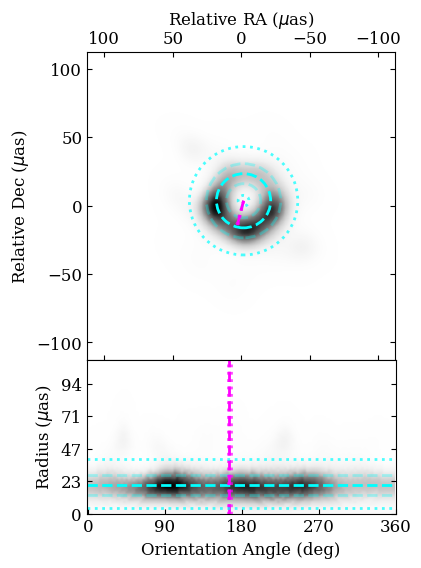

In [1]:
import ehtim as eh
from BASIS.modules import ringFitting
import matplotlib.pyplot as plt
import numpy as np

model_img = '../data/fits/SR1_M87_2017_101.fits'

model_img = eh.image.load_fits(model_img)

ringfitter = ringFitting.RingFit(model_img.imarr(), fov=model_img.fovx()*1e6*206265, interp_factor=2, blur_uas=10, total_flux=1)
ringfitter.run_all(verbose=True)

height_ratio = [6,3]
fig, ax = plt.subplots(2,1, figsize=(np.sum(height_ratio),height_ratio[0]), height_ratios=height_ratio)
plt.subplots_adjust(hspace=0.0, wspace=0.0)

save_path = None
ringfitter.plot_all(ax[0], ax[1], cmap='Greys', ratio=height_ratio, save_path=save_path)
